<div style="text-align: center; border: 2px solid #2c3e50; padding: 20px; border-radius: 15px; background-color: #ecf0f1; font-family: Tahoma, Arial, sans-serif;">
    <h1 style="color: #2c3e50; margin-bottom: 5px;">Fundamentals of Artificial Intelligence</h1>
    <h2 style="color: #2980b9; margin-top: 0;">Final Project : Churn Modeling</h2>
    <hr style="border: 1
        px solid #bdc3c7; width: 60%;">
    <p style="font-size: 16px; color: #34495e;"><b>Author:</b> Mohammad Hossein Bakhshian</p>
    <p style="font-size: 16px; color: #34495e;"><b>Student ID:</b> [40215443]

In [1]:
# Step 1: Import Libraries and Load the Dataset
import numpy as np
import pandas as pd

In [2]:
# Load the bank churn dataset
df = pd.read_csv(r"C:\Users\Asus\Desktop\S6\Primitive_AI_star\My_Final_Project\Churn.csv")

In [3]:
# Display the first 5 rows to understand the structure of our data
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,NaN,NaN,NaN,NaN,NaN
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,NaN,NaN,NaN,NaN,NaN
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,NaN,NaN,NaN,NaN,NaN
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaN,NaN,NaN,NaN,NaN
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display the last 5 rows to understand the structure of our data
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,NaN,NaN,NaN,NaN,NaN
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,NaN,NaN,NaN,NaN,NaN
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,NaN,NaN,NaN,NaN,NaN
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,NaN,NaN,NaN,NaN,NaN
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0,NaN,NaN,NaN,NaN,NaN


In [5]:
# display the basic information of our data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
 14  Unnamed: 14      0 non-null      float64
 15  Unnamed: 15      0 non-null      float64
 16  Unnamed: 16      0 non-null      float64
 17  Unnamed: 17  

In [6]:
# Step 2: Data Cleaning and Descriptive Statistics

# 1. Dropping specific redundant columns safely
# Using errors='ignore' prevents KeyError if the cell is executed multiple times
columns_to_drop = ["RowNumber", "CustomerId", "Surname"]
df = df.drop(columns=columns_to_drop, errors="ignore")

# 2. Dropping completely empty columns (e.g., 'Unnamed: 14')
# The parameter `how='all'` ensures a column is dropped only if all its values are NaN
df = df.dropna(axis=1, how='all')

# 3. Generating descriptive statistics for numerical features
# The output is transposed (.T) for better readability 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


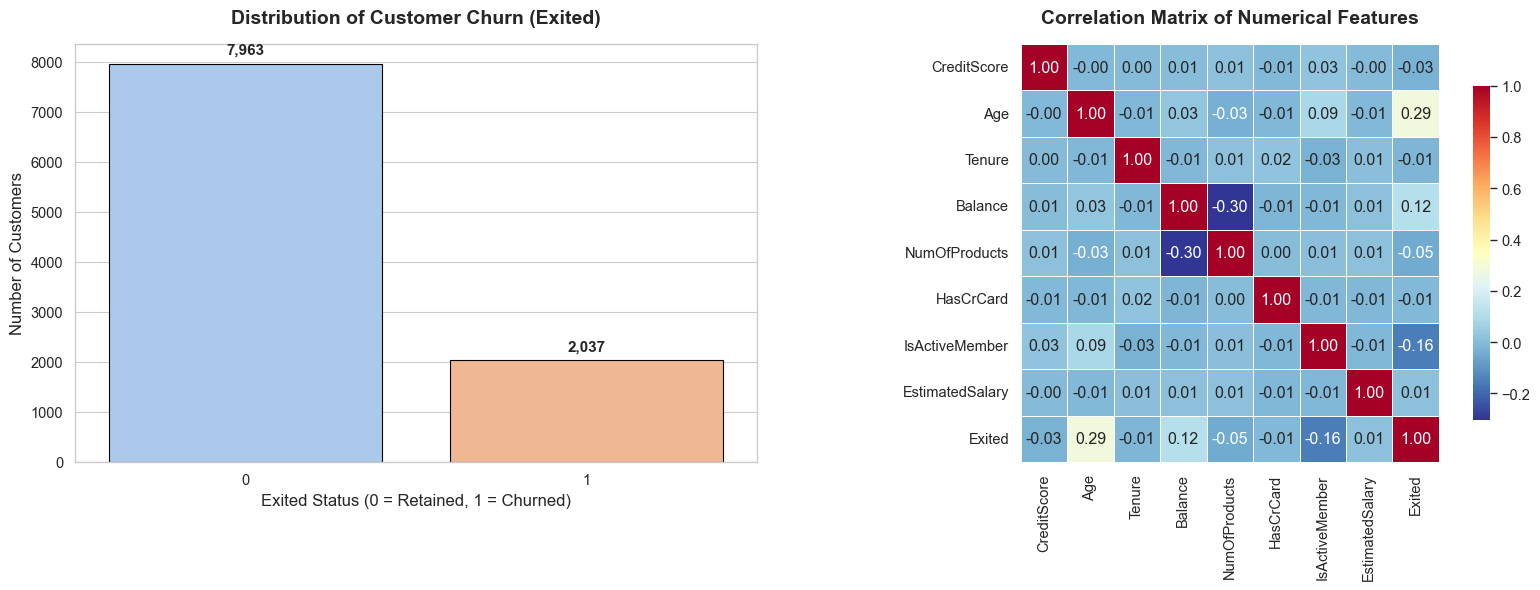

In [7]:
# Step 3: Exploratory Data Analysis (EDA) - Updated
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean and professional visual style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Distribution of Churn (Exited) ---
# Fixed the FutureWarning by adding hue and legend=False
sns.countplot(data=df, x='Exited', hue='Exited', ax=axes[0], palette='pastel', legend=False, edgecolor='black')
axes[0].set_title('Distribution of Customer Churn (Exited)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Exited Status (0 = Retained, 1 = Churned)', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)

# Add value counts on top of bars for better readability
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# --- Plot 2: Correlation Heatmap of Numerical Features ---
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()

# Draw the heatmap with a professional color map (cmap)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            square=True, ax=axes[1], cbar_kws={"shrink": .8}, linewidths=0.5)
axes[1].set_title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', pad=15)

# Adjust layout and save the plot
plt.tight_layout()

plt.savefig('eda_plots.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 4: Data Preprocessing

# 1. Encoding categorical variables (Geography and Gender)
# We use drop_first=True to avoid the dummy variable trap (multicollinearity)
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# 2. Separating Features (X) and Target (y)
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

# 3. Train-Test Split (80% Train, 20% Test)
# stratify=y ensures that the proportion of churned/retained customers is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Feature Scaling (Standardization)
# MLPs are sensitive to feature scaling, so we scale features to have mean=0 and variance=1
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
# Only transform the test data (do NOT fit) to prevent data leakage
X_test_scaled = scaler.transform(X_test)

# Display the shape of our final datasets
print("Data Preprocessing Completed Successfully!")
print("-" * 40)
print(f"Training features (X_train_scaled) shape: {X_train_scaled.shape}")
print(f"Testing features (X_test_scaled) shape:   {X_test_scaled.shape}")
print(f"Training target (y_train) shape:          {y_train.shape}")
print(f"Testing target (y_test) shape:            {y_test.shape}")


Data Preprocessing Completed Successfully!
----------------------------------------
Training features (X_train_scaled) shape: (8000, 11)
Testing features (X_test_scaled) shape:   (2000, 11)
Training target (y_train) shape:          (8000,)
Testing target (y_test) shape:            (2000,)


Initializing Neural Network Models...
Training with Mini-Batch Gradient Descent (Batch Size = 32)...
Training with Full-Batch Gradient Descent (Batch Size = Full Dataset)...
--------------------------------------------------
Mini-Batch Training Time: 31.35 seconds
Full-Batch Training Time: 7.50 seconds


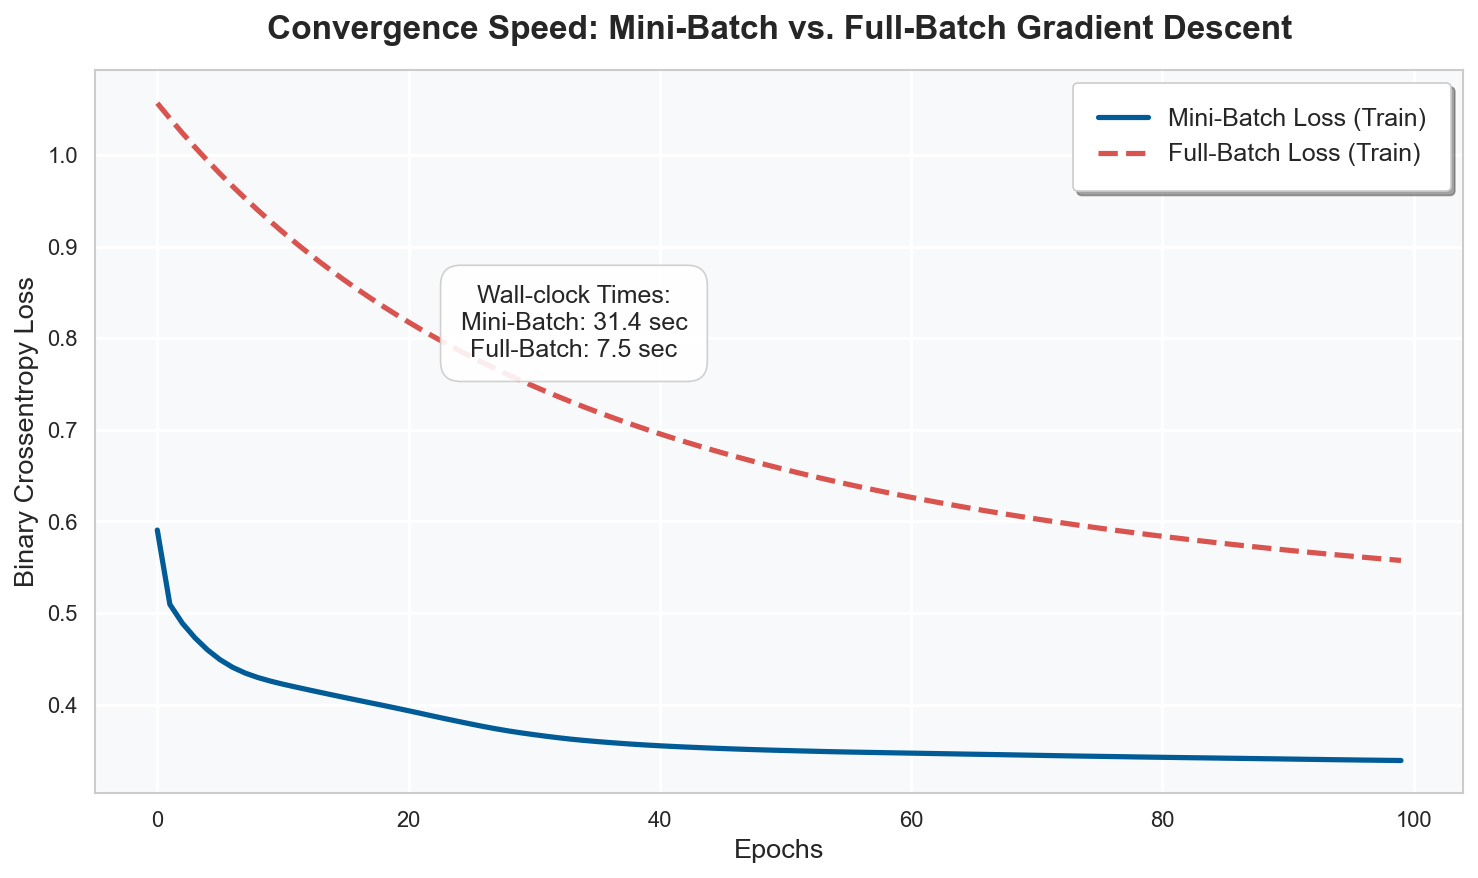

In [9]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import time

# Setting random seed for reproducibility
tf.random.set_seed(42)

# Function to create our base MLP model architecture (Fixed Warning)
def create_model():
    model = Sequential([
        # Explicit Input layer for newer Keras versions to avoid warnings
        Input(shape=(X_train_scaled.shape[1],), name='Input_Layer'),
        Dense(16, activation='relu', name='Hidden_Layer_1'),
        Dense(8, activation='relu', name='Hidden_Layer_2'),
        Dense(1, activation='sigmoid', name='Output_Layer')
    ])
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

print("Initializing Neural Network Models...")

# ---------------------------------------------------------
# 1. Mini-Batch Gradient Descent Training
# ---------------------------------------------------------
print("Training with Mini-Batch Gradient Descent (Batch Size = 32)...")
model_mini = create_model()
start_time_mini = time.time()

history_mini = model_mini.fit(X_train_scaled, y_train, 
                              epochs=100, 
                              batch_size=32, 
                              validation_split=0.2, 
                              verbose=0)
time_mini = time.time() - start_time_mini

# ---------------------------------------------------------
# 2. Full-Batch Gradient Descent Training
# ---------------------------------------------------------
print("Training with Full-Batch Gradient Descent (Batch Size = Full Dataset)...")
model_full = create_model()
start_time_full = time.time()

# Dynamically using the exact size of the training set for full batch
full_batch_size = X_train_scaled.shape[0]
history_full = model_full.fit(X_train_scaled, y_train, 
                              epochs=100, 
                              batch_size=full_batch_size, 
                              validation_split=0.2, 
                              verbose=0)
time_full = time.time() - start_time_full

print("-" * 50)
print(f"Mini-Batch Training Time: {time_mini:.2f} seconds")
print(f"Full-Batch Training Time: {time_full:.2f} seconds")

# ---------------------------------------------------------
# 3. Professional and Beautiful Loss Curve Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6), dpi=150) # Higher DPI for better resolution

# Setting a beautiful background
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

# Plotting the lines with distinct colors and line styles
ax.plot(history_mini.history['loss'], label='Mini-Batch Loss (Train)', color='#005b96', linewidth=2.5)
ax.plot(history_full.history['loss'], label='Full-Batch Loss (Train)', color='#d9534f', linewidth=2.5, linestyle='--')

# Adding Titles and Labels with elegant fonts
ax.set_title('Convergence Speed: Mini-Batch vs. Full-Batch Gradient Descent', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Epochs', fontsize=13, fontweight='medium')
ax.set_ylabel('Binary Crossentropy Loss', fontsize=13, fontweight='medium')

# Enhancing the Grid
ax.grid(color='white', linestyle='-', linewidth=1.5)

# Adding the Legend with a nice shadow and frame
legend = ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True, borderpad=1)
legend.get_frame().set_facecolor('white')

# Adding an annotation box inside the plot to show the training times
time_text = f"Wall-clock Times:\nMini-Batch: {time_mini:.1f} sec\nFull-Batch: {time_full:.1f} sec"
ax.text(0.35, 0.65, time_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='center', horizontalalignment='center',
        bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='round,pad=0.8', alpha=0.9))

plt.tight_layout()
# Saving the enhanced plot with a new name
plt.savefig('loss_comparison_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()


Evaluating the Mini-Batch Model on Test Data...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.75      0.46      0.57       407

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



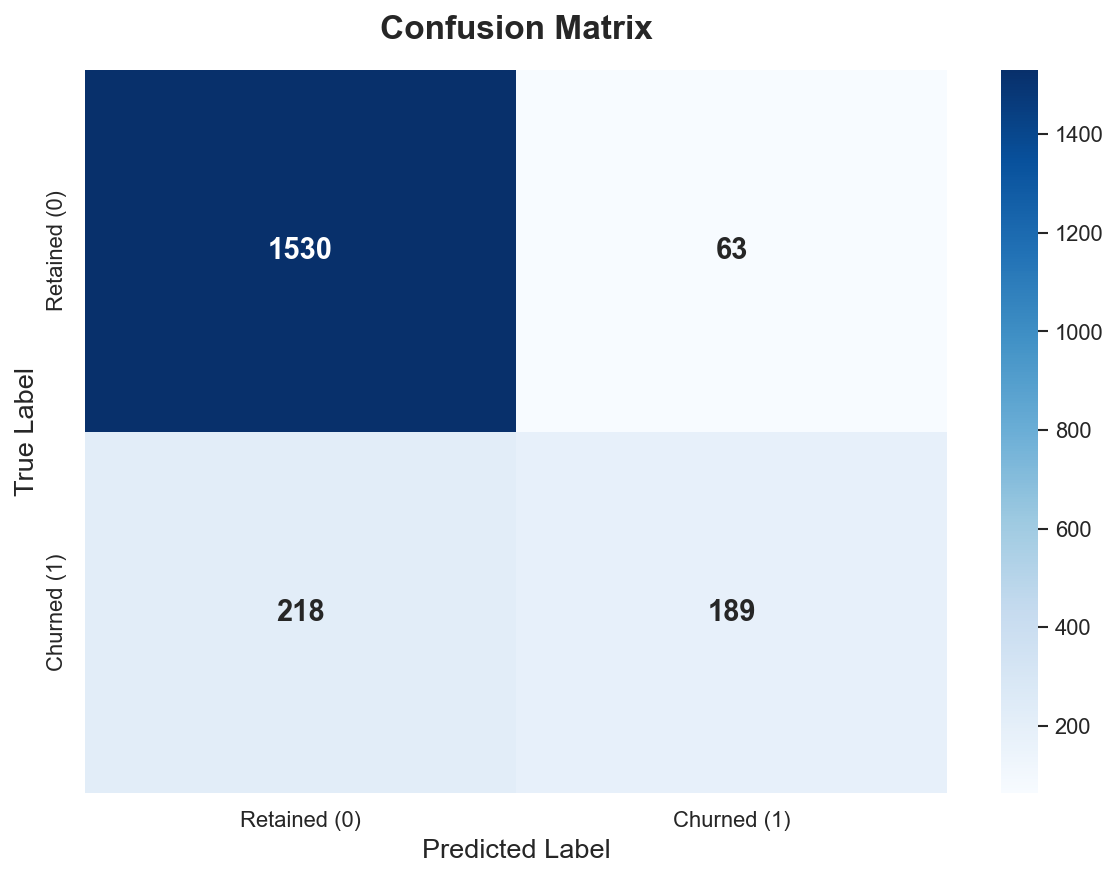

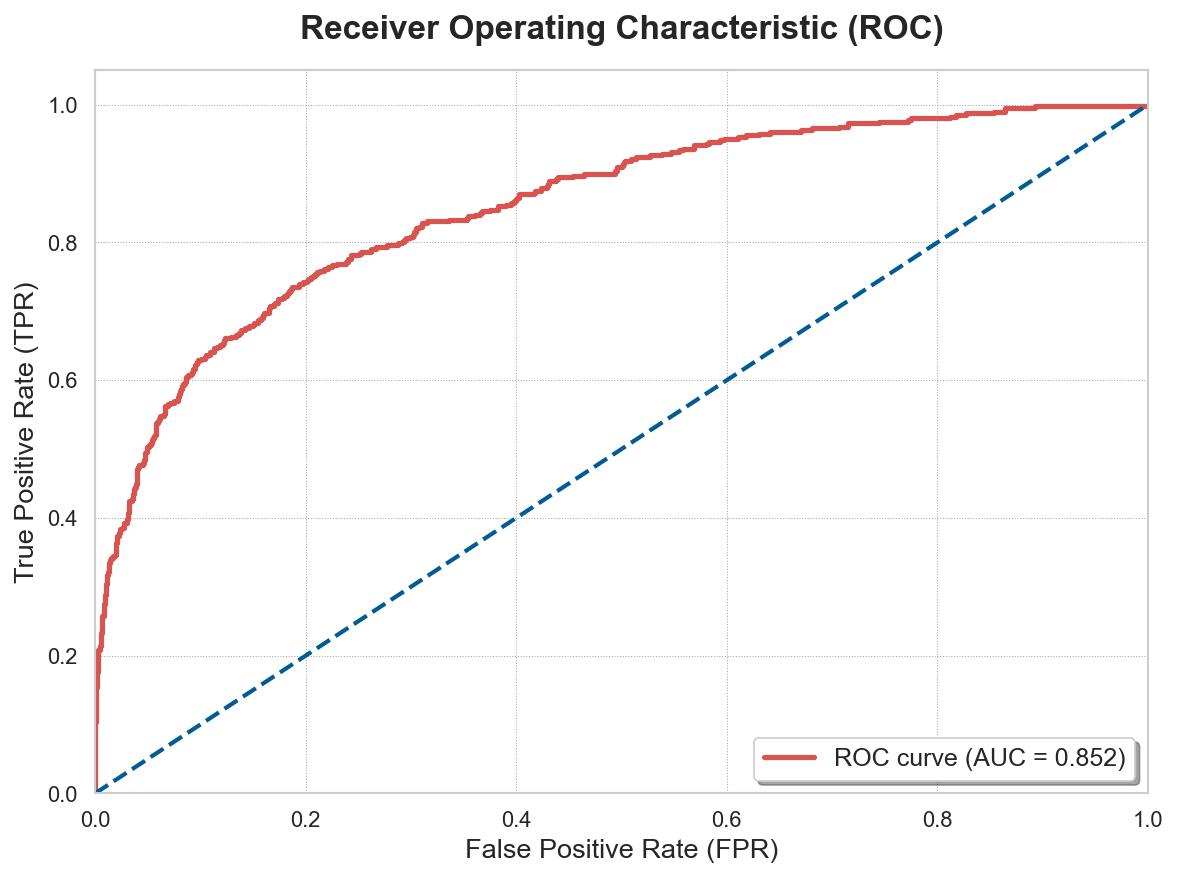

In [10]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("Evaluating the Mini-Batch Model on Test Data...")
# Step 5: 
# 1. Predictions
# Since output is sigmoid, we use 0.5 as threshold
y_pred_probs = model_mini.predict(X_test_scaled)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# 2. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_classes))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=13, fontweight='medium')
plt.ylabel('True Label', fontsize=13, fontweight='medium')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# 4. ROC Curve & AUC Visualization
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6), dpi=150)
plt.plot(fpr, tpr, color='#d9534f', linewidth=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#005b96', linestyle='--', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=13, fontweight='medium')
plt.ylabel('True Positive Rate (TPR)', fontsize=13, fontweight='medium')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(color='gray', linestyle=':', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()
